In [ ]:
# 🔧 Cell 1: Test Jupyter Environment
# Simple test to verify Jupyter is working correctly
print("hello world")

hello world


In [ ]:
# 📦 Cell 2: Import Core Libraries
# Import essential data science libraries for backtesting
import pandas as pd
import numpy as np
print("✅ Jupyter is working!")

✅ Jupyter is working!


In [ ]:
# 📚 Cell 3: Import All Required Libraries
# Import all necessary libraries for data fetching, API integration, and visualization
import os
import pyotp  # Time-based OTP for broker authentication
import datetime as dt  # Date and time handling
import pandas as pd  # Data manipulation and analysis
import numpy as np  # Numerical computing
import matplotlib.pyplot as plt  # Data visualization
import time  # Timing and delays
from SmartApi import SmartConnect  # Angel Broking API for live data
from dateutil.relativedelta import relativedelta  # Relative date calculations
from IPython.display import display  # Display rich content in notebooks
%matplotlib inline  # Inline matplotlib plots in Jupyter

In [ ]:
# 🔐 Cell 4: Load API Credentials
# Read API credentials from key.txt file
# Format: API_KEY REFRESH_TOKEN CLIENT_CODE PASSWORD TOTP_SECRET
with open("key.txt", "r") as file:
    key_secret = file.read().split()

In [ ]:
# 🚀 Cell 5: Authenticate with Broker API
# Initialize SmartConnect API session using Angel Broking credentials
# Generates session token for API calls
try:
    smart_api = SmartConnect(api_key=key_secret[0])
    # Generate authentication session with credentials and TOTP
    data = smart_api.generateSession(
        clientCode=key_secret[2],
        password=key_secret[3],
        totp=pyotp.TOTP(key_secret[4]).now()  # Time-based OTP for security
    )
    if data['status']:
        auth_token = data['data']['jwtToken']
        print("✅ Login successful.")
    else:
        print(f"❌ Login failed: {data['message']}")
except Exception as e:
    print(f"❌ Login failed: {e}")

[I 260106 22:07:17 smartConnect:121] in pool


✅ Login successful.


In [ ]:
# ⚙️ Cell 6: Define Trading Parameters
# Configuration parameters for backtest simulation
CAPITAL = 300000  # Starting capital in INR
LEVERAGE = 5  # Leverage multiplier for position sizing
MAX_TRADES = 2  # Maximum concurrent open positions
VOLUME_FILTER = True  # Enable volume filter for pattern validation
TRADING_DAYS = 40  # Historical data lookback period in days

In [ ]:
# 📊 Cell 7: Define Technical Indicators and Data Fetching Functions

def compute_rsi(series, period=14):
    """
    Calculate Relative Strength Index (RSI)
    
    Args:
        series: Price series (pandas Series)
        period: Lookback period (default: 14)
    
    Returns:
        RSI values as pandas Series (0-100)
    """
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def fetch_candles(symbol, exchange, token, days=TRADING_DAYS, interval="FIVE_MINUTE"):
    """
    Fetch candlestick data from broker API and compute technical indicators
    
    Args:
        symbol: Stock symbol (e.g., 'INFY')
        exchange: Stock exchange ('NSE' or 'BSE')
        token: Instrument token from broker
        days: Historical lookback period
        interval: Candle interval ('FIVE_MINUTE', 'ONE_MINUTE', etc.)
    
    Returns:
        DataFrame with OHLCV, MA20, ATR, and RSI
    """
    fromdate = (dt.datetime.now() - relativedelta(days=days)).strftime('%Y-%m-%d 09:15')
    todate = dt.datetime.now().strftime('%Y-%m-%d %H:%M')
    params = {
        "exchange": exchange,
        "symboltoken": token,
        "interval": interval,
        "fromdate": fromdate,
        "todate": todate
    }
    try:
        time.sleep(3)  # Rate limiting for API
        res = smart_api.getCandleData(params)
        if res['status'] and res['data']:
            df = pd.DataFrame(res['data'], columns=["datetime", "open", "high", "low", "close", "volume"])
            df["datetime"] = pd.to_datetime(df["datetime"])
            df.set_index("datetime", inplace=True)
            if len(df) >= 20:
                # Compute technical indicators
                df["MA20"] = df["close"].rolling(window=20).mean()
                df["ATR"] = pd.concat([
                    df["high"] - df["low"],
                    abs(df["high"] - df["close"].shift()),
                    abs(df["low"] - df["close"].shift())
                ], axis=1).max(axis=1).rolling(window=14).mean()
                df["RSI"] = compute_rsi(df["close"], 14)
            return df
        else:
            print(f"⚠️ No data for {symbol}: {res.get('message', 'Unknown error')}")
            return pd.DataFrame()
    except Exception as e:
        print(f"❌ Error fetching data for {symbol}: {e}")
        return pd.DataFrame()

In [ ]:
# 🔍 Cell 8: Define Pattern Detection Functions

def detect_three_white_soldiers(df):
    """
    Detect "Three White Soldiers" bullish candlestick pattern
    
    Pattern characteristics:
    - Three consecutive bullish (green) candles
    - Each closing price higher than the previous close
    - Each opening price higher than the previous open
    - Optional: Volume confirmation (increasing volume)
    
    Args:
        df: OHLCV DataFrame with technical indicators
    
    Returns:
        DataFrame with '3WS' boolean column marking pattern occurrences
    """
    df["3WS"] = False
    for i in range(2, len(df)):
        c1, c2, c3 = df.iloc[i-2], df.iloc[i-1], df.iloc[i]
        conditions = [
            c1['close'] > c1['open'] * 1.002,  # Candle 1 bullish
            c2['close'] > c2['open'] * 1.002,  # Candle 2 bullish
            c3['close'] > c3['open'] * 1.002,  # Candle 3 bullish
            c2['open'] > c1['open'],  # Candle 2 opens higher
            c3['open'] > c2['open'],  # Candle 3 opens higher
            c2['close'] > c1['close'],  # Candle 2 closes higher
            c3['close'] > c2['close']   # Candle 3 closes higher
        ]
        if VOLUME_FILTER:
            conditions.append(c1['volume'] < c2['volume'] < c3['volume'])
        if all(conditions):
            df.at[df.index[i], "3WS"] = True
    return df

def detect_three_black_crows(df):
    """
    Detect "Three Black Crows" bearish candlestick pattern
    
    Pattern characteristics:
    - Three consecutive bearish (red) candles
    - Each closing price lower than the previous close
    - Each opening price lower than the previous open
    - Optional: Volume confirmation (increasing volume)
    
    Args:
        df: OHLCV DataFrame with technical indicators
    
    Returns:
        DataFrame with '3BC' boolean column marking pattern occurrences
    """
    df["3BC"] = False
    for i in range(2, len(df)):
        c1, c2, c3 = df.iloc[i-2], df.iloc[i-1], df.iloc[i]
        conditions = [
            c1['close'] < c1['open'] * 0.998,  # Candle 1 bearish
            c2['close'] < c2['open'] * 0.998,  # Candle 2 bearish
            c3['close'] < c3['open'] * 0.998,  # Candle 3 bearish
            c2['open'] < c1['open'],  # Candle 2 opens lower
            c3['open'] < c2['open'],  # Candle 3 opens lower
            c2['close'] < c1['close'],  # Candle 2 closes lower
            c3['close'] < c2['close']   # Candle 3 closes lower
        ]
        if VOLUME_FILTER:
            conditions.append(c1['volume'] < c2['volume'] < c3['volume'])
        if all(conditions):
            df.at[df.index[i], "3BC"] = True
    return df

In [ ]:
# 📈 Cell 9: Define Backtest Engine

def backtest(all_dfs, capital=CAPITAL, leverage=LEVERAGE, max_trades=MAX_TRADES):
    """
    Execute backtest simulation on candlestick pattern strategy
    
    Entry Rules:
    - LONG: Three White Soldiers pattern detected, close > MA20, RSI < 70
    - SHORT: Three Black Crows pattern detected, close < MA20, RSI > 30
    
    Exit Rules:
    - Profit Target: 1.5 * ATR from entry
    - Stop Loss: 1% below entry (long) / above entry (short)
    - Trailing Stop: 1% from highest point (long) / lowest point (short)
    - Time Exit: After 6 candles (30 minutes)
    
    Position Sizing:
    - Risk per trade: 1% of account
    - Qty based on risk, max leverage constraint
    - Max concurrent positions: max_trades parameter
    
    Args:
        all_dfs: Dictionary of symbol -> DataFrame mapping
        capital: Starting capital in INR
        leverage: Account leverage multiplier
        max_trades: Maximum concurrent open positions
    
    Returns:
        Tuple: (trades_df, final_capital, equity_df, concurrent_df)
    """
    trades = []
    current_capital = capital
    open_positions = {}
    equity_curve = []
    concurrent_trades = []

    # Synchronize all timestamps across all stocks
    all_timestamps = sorted(set().union(*[df.index for df in all_dfs.values()]))

    for timestamp in all_timestamps:
        # Calculate equity (mark-to-market)
        equity = current_capital
        for stock, pos in open_positions.items():
            if timestamp in all_dfs[stock].index:
                price_now = all_dfs[stock].loc[timestamp]['close']
                if pos['direction'] == 'long':
                    equity += (price_now - pos['entry_price']) * pos['qty']
                elif pos['direction'] == 'short':
                    equity += (pos['entry_price'] - price_now) * pos['qty']
        equity_curve.append({"timestamp": timestamp, "equity": equity})

        for stock, df in all_dfs.items():
            if timestamp not in df.index:
                continue
            idx = df.index.get_loc(timestamp)

            # 🔴 EXIT LOGIC
            if stock in open_positions:
                pos = open_positions[stock]
                price_now = df.iloc[idx]["close"]
                atr = df.iloc[idx]["ATR"]
                
                if pos['direction'] == 'long':
                    # Track highest price for trailing stop
                    high_price = max(pos.get('high_price', pos['entry_price']), price_now)
                    trailing_stop = high_price * 0.99
                    stop_loss = pos['entry_price'] * 0.99
                    profit_target = pos['entry_price'] + (1.5 * atr if not pd.isna(atr) else pos['entry_price'] * 0.02)
                    
                    # Check exit conditions
                    if idx >= pos['index'] + 6 or price_now >= profit_target or price_now <= stop_loss or price_now <= trailing_stop:
                        exit_price = price_now
                        pnl = (exit_price - pos['entry_price']) * pos['qty']
                        current_capital += pnl
                        trades.append({
                            "Stock": stock,
                            "Direction": "long",
                            "Entry Time": pos['entry_time'],
                            "Exit Time": timestamp,
                            "Entry": pos['entry_price'],
                            "Exit": exit_price,
                            "Qty": pos['qty'],
                            "Gross PnL": pnl,
                            "Net PnL": pnl,
                            "Trade Duration (min)": (timestamp - pos['entry_time']).total_seconds() / 60,
                            "Reason": "Timeout" if idx >= pos['index'] + 6 else "Profit Target" if price_now >= profit_target else "Stop Loss" if price_now <= stop_loss else "Trailing Stop"
                        })
                        del open_positions[stock]
                    else:
                        pos['high_price'] = high_price

                elif pos['direction'] == 'short':
                    # Track lowest price for trailing stop
                    low_price = min(pos.get('low_price', pos['entry_price']), price_now)
                    trailing_stop = low_price * 1.01
                    stop_loss = pos['entry_price'] * 1.01
                    profit_target = pos['entry_price'] - (1.5 * atr if not pd.isna(atr) else pos['entry_price'] * 0.02)
                    
                    # Check exit conditions
                    if idx >= pos['index'] + 6 or price_now <= profit_target or price_now >= stop_loss or price_now >= trailing_stop:
                        exit_price = price_now
                        pnl = (pos['entry_price'] - exit_price) * pos['qty']
                        current_capital += pnl
                        trades.append({
                            "Stock": stock,
                            "Direction": "short",
                            "Entry Time": pos['entry_time'],
                            "Exit Time": timestamp,
                            "Entry": pos['entry_price'],
                            "Exit": exit_price,
                            "Qty": pos['qty'],
                            "Gross PnL": pnl,
                            "Net PnL": pnl,
                            "Trade Duration (min)": (timestamp - pos['entry_time']).total_seconds() / 60,
                            "Reason": "Timeout" if idx >= pos['index'] + 6 else "Profit Target" if price_now <= profit_target else "Stop Loss" if price_now >= stop_loss else "Trailing Stop"
                        })
                        del open_positions[stock]
                    else:
                        pos['low_price'] = low_price

            # 🟢 ENTRY LOGIC
            if stock not in open_positions and idx >= 3:
                direction = None
                
                # Pattern detection with additional filters
                if df.iloc[idx]["3WS"] and df.iloc[idx]["close"] > df.iloc[idx]["MA20"] and df.iloc[idx]["RSI"] < 70:
                    direction = 'long'
                elif df.iloc[idx]["3BC"] and df.iloc[idx]["close"] < df.iloc[idx]["MA20"] and df.iloc[idx]["RSI"] > 30:
                    direction = 'short'
                else:
                    continue

                # Position sizing calculation
                entry_price = df.iloc[idx]["open"]
                atr = df.iloc[idx]["ATR"]
                stop_distance = entry_price * 0.01
                risk_per_trade = 0.01 * current_capital  # 1% risk per trade
                qty_risk = int(risk_per_trade / stop_distance)
                
                # Leverage constraint
                max_position_size = leverage * current_capital
                valid_quantities = [q for q in [100, 200, 500, 1000, 2000, 3000, 4000, 5000] if q * entry_price <= max_position_size]
                if not valid_quantities:
                    continue
                qty = min(qty_risk, max(valid_quantities))
                capital_required = (qty * entry_price) / leverage
                capital_in_use = sum(pos['capital_used'] for pos in open_positions.values())
                available_capital = current_capital - capital_in_use
                
                # Check if trade is allowed
                if len(open_positions) >= max_trades or capital_required > available_capital:
                    continue

                # Open position
                open_positions[stock] = {
                    'direction': direction,
                    'entry_time': timestamp,
                    'qty': qty,
                    'entry_price': entry_price,
                    'capital_used': capital_required,
                    'index': idx,
                    'high_price': entry_price if direction == 'long' else None,
                    'low_price': entry_price if direction == 'short' else None
                }

        concurrent_trades.append({"timestamp": timestamp, "open_trades": len(open_positions)})

    # Create output DataFrames
    trades_df = pd.DataFrame(trades)
    equity_df = pd.DataFrame(equity_curve)
    concurrent_df = pd.DataFrame(concurrent_trades)
    return trades_df, current_capital, equity_df, concurrent_df

In [ ]:
# 📋 Cell 10: Define Stock Universe
# Dictionary mapping stock symbols to exchange and broker instrument tokens
# These are NSE (National Stock Exchange) stocks from various sectors
tokens = {
    "RVNL": {"exchange": "NSE", "token": "9552"}, "IFCI": {"exchange": "NSE", "token": "1491"},
    "IRFC": {"exchange": "NSE", "token": "2029"}, "APOLLO": {"exchange": "NSE", "token": "1134"},
    "SUZLON": {"exchange": "NSE", "token": "12018"}, "ADANIGREEN": {"exchange": "NSE", "token": "3563"},
    "ADANIPORTS": {"exchange": "NSE", "token": "15083"}, "ASTRAMICRO": {"exchange": "NSE", "token": "11618"},
    "AZAD": {"exchange": "NSE", "token": "20905"}, "BEL": {"exchange": "NSE", "token": "383"},
    "RITES": {"exchange": "NSE", "token": "3761"}, "WELCORP": {"exchange": "NSE", "token": "11821"},
    "MMTC": {"exchange": "NSE", "token": "17957"}, "NAZARA": {"exchange": "NSE", "token": "2987"},
    "BHARTIHEXA": {"exchange": "NSE", "token": "23489"}, "JIOFIN": {"exchange": "NSE", "token": "18143"},
    "LTFOODS": {"exchange": "NSE", "token": "13816"}, "BSE": {"exchange": "NSE", "token": "19585"},
    "PAYTM": {"exchange": "NSE", "token": "6705"}, "ATGL": {"exchange": "NSE", "token": "6066"},
    "WAAREEENER": {"exchange": "NSE", "token": "25907"}, "AEROFLEX": {"exchange": "NSE", "token": "18268"},
    "HFCL": {"exchange": "NSE", "token": "21951"}, "BANDHANBNK": {"exchange": "NSE", "token": "2263"},
    "RBLBANK": {"exchange": "NSE", "token": "18391"}, "CGCL": {"exchange": "NSE", "token": "20329"},
    "NBCC": {"exchange": "NSE", "token": "31415"}, "BDL": {"exchange": "NSE", "token": "2144"},
    "INDIANB": {"exchange": "NSE", "token": "14309"}, "PETRONET": {"exchange": "NSE", "token": "11351"},
    "CGPOWER": {"exchange": "NSE", "token": "760"}, "FEDERALBNK": {"exchange": "NSE", "token": "1023"},
    "FORTIS": {"exchange": "NSE", "token": "14592"}, "PBFINTECH": {"exchange": "NSE", "token": "6656"},
    "MAXHEALTH": {"exchange": "NSE", "token": "22377"}, "UNIONBANK": {"exchange": "NSE", "token": "10753"},
    "SJVN": {"exchange": "NSE", "token": "18883"}, "LUMAXTECH": {"exchange": "NSE", "token": "14014"},
    "GRSE": {"exchange": "NSE", "token": "5475"}, "MAZDOCK": {"exchange": "NSE", "token": "509"},
    "ITI": {"exchange": "NSE", "token": "1675"}, "BANKINDIA": {"exchange": "NSE", "token": "4745"},
    "TITAGARH": {"exchange": "NSE", "token": "15414"}, "IRCON": {"exchange": "NSE", "token": "4986"},
    "IRCTC": {"exchange": "NSE", "token": "13611"}, "RECLTD": {"exchange": "NSE", "token": "15355"},
    "TEJASNET": {"exchange": "NSE", "token": "21131"}, "INDUSTOWER": {"exchange": "NSE", "token": "29135"},
    "JUBLFOOD": {"exchange": "NSE", "token": "18096"}, "SIEMENS": {"exchange": "NSE", "token": "3150"},
    "VOLTAS": {"exchange": "NSE", "token": "3718"}, "LUPIN": {"exchange": "NSE", "token": "10440"},
    "INFY": {"exchange": "NSE", "token": "1594"}, "HCLTECH": {"exchange": "NSE", "token": "7229"},
    "BHARTIARTL": {"exchange": "NSE", "token": "10604"}, "HUBTOWN": {"exchange": "NSE", "token": "14203"},
    "IGL": {"exchange": "NSE", "token": "11262"}, "VMM": {"exchange": "NSE", "token": "27969"},
    "HDFCBANK": {"exchange": "NSE", "token": "1330"}, "ICICIBANK": {"exchange": "NSE", "token": "11991"},
    "SBIN": {"exchange": "NSE", "token": "3045"}, "AXISBANK": {"exchange": "NSE", "token": "5900"},
    "KOTAKBANK": {"exchange": "NSE", "token": "1922"}, "INDUSINDBK": {"exchange": "NSE", "token": "5258"},
    "BANKBARODA": {"exchange": "NSE", "token": "4668"}, "PNB": {"exchange": "NSE", "token": "2733"},
    "IDFCFIRSTB": {"exchange": "NSE", "token": "1801"}, "AUBANK": {"exchange": "NSE", "token": "17656"}
}

In [ ]:
# 🔄 Cell 11: Fetch Data and Detect Patterns
# Iterate through all stocks, fetch candlestick data, and detect trading patterns
# This may take several minutes due to API rate limiting (3-second delay per stock)
all_dfs = {}
no_data_stocks = []

for stock, info in tokens.items():
    print(f"🔍 Fetching data for {stock}...")
    df = fetch_candles(stock, info["exchange"], info["token"])
    if not df.empty:
        df = detect_three_white_soldiers(df)
        df = detect_three_black_crows(df)
        all_dfs[stock] = df
    else:
        no_data_stocks.append(stock)

if no_data_stocks:
    print(f"⚠️ No data for: {', '.join(no_data_stocks)}")
else:
    print("✅ All stock data fetched successfully.")

🔍 Fetching data for RVNL...
🔍 Fetching data for IFCI...
🔍 Fetching data for IRFC...
🔍 Fetching data for APOLLO...
🔍 Fetching data for SUZLON...
🔍 Fetching data for ADANIGREEN...
🔍 Fetching data for ADANIPORTS...
🔍 Fetching data for ASTRAMICRO...
🔍 Fetching data for AZAD...
🔍 Fetching data for BEL...
🔍 Fetching data for RITES...
🔍 Fetching data for WELCORP...
🔍 Fetching data for MMTC...
🔍 Fetching data for NAZARA...
🔍 Fetching data for BHARTIHEXA...
🔍 Fetching data for JIOFIN...
🔍 Fetching data for LTFOODS...
🔍 Fetching data for BSE...
🔍 Fetching data for PAYTM...
🔍 Fetching data for ATGL...
🔍 Fetching data for WAAREEENER...
🔍 Fetching data for AEROFLEX...
🔍 Fetching data for HFCL...
🔍 Fetching data for BANDHANBNK...
🔍 Fetching data for RBLBANK...
🔍 Fetching data for CGCL...
🔍 Fetching data for NBCC...
🔍 Fetching data for BDL...
🔍 Fetching data for INDIANB...
🔍 Fetching data for PETRONET...
🔍 Fetching data for CGPOWER...
🔍 Fetching data for FEDERALBNK...
🔍 Fetching data for FORTIS...
🔍 


🚀 Running backtest...


,Total Trades,Long Trades,Short Trades,Total P&L,Long P&L,Short P&L,Win Rate (%),Long Win Rate (%),Short Win Rate (%),Max Drawdown (%),Sharpe Ratio
0,56,34,22,81462.03,34790.11,46671.92,75.0,76.470588,72.727273,2.360392,7.562505


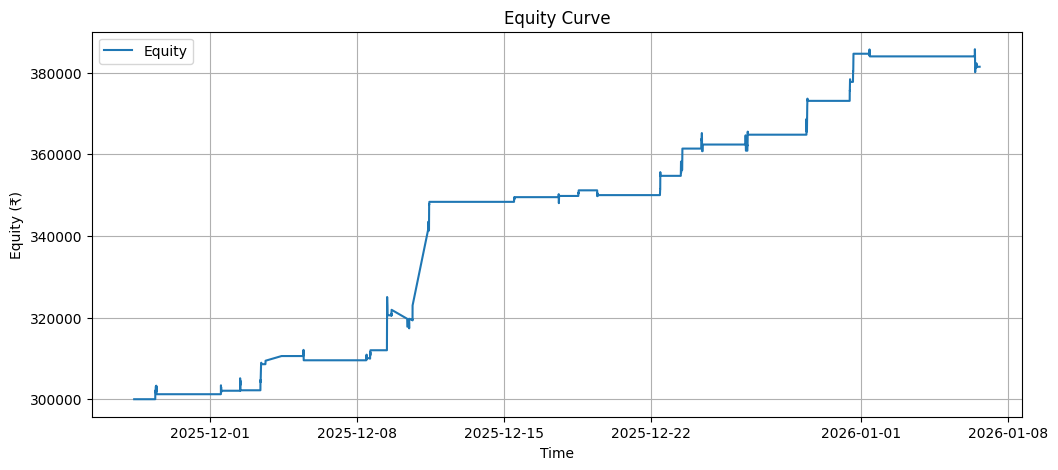

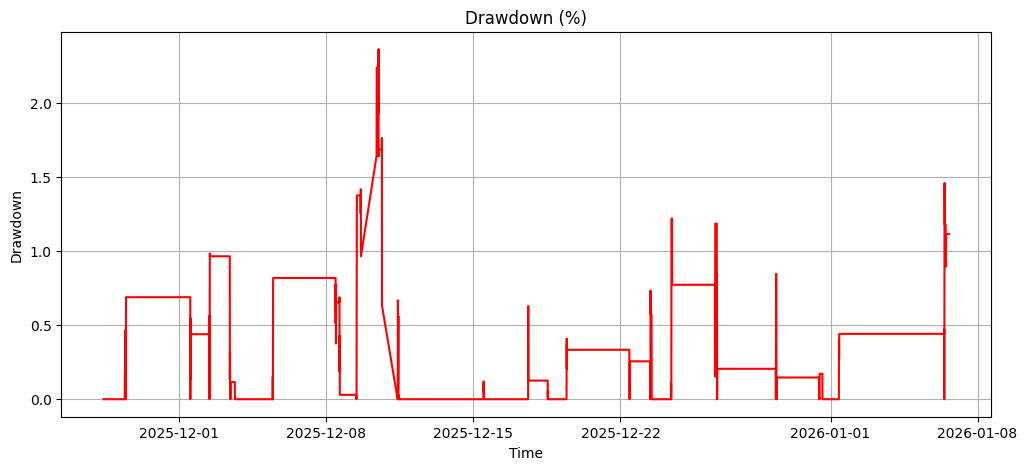

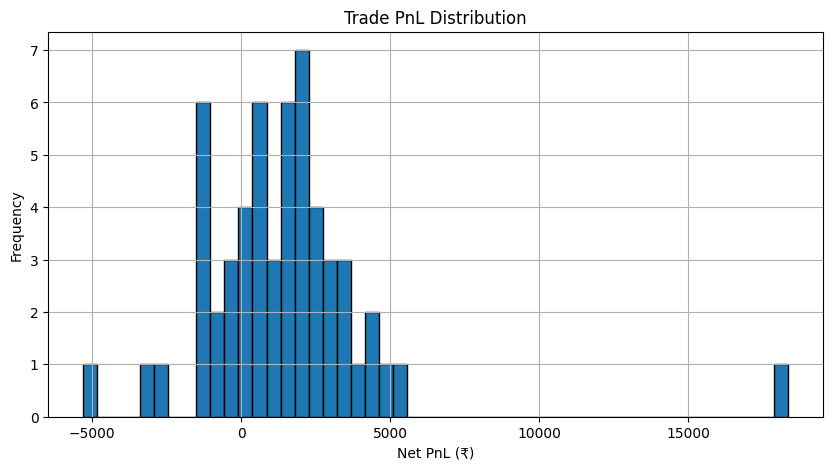

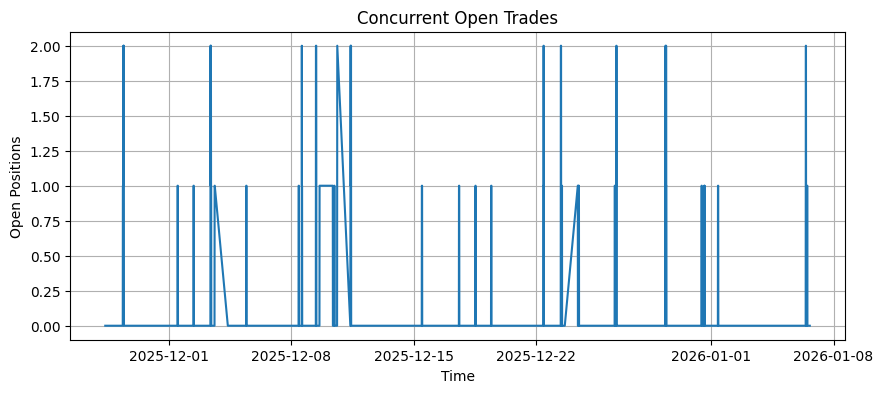

In [ ]:
# 📊 Cell 12: Backtest Execution and Performance Analysis
# Run the backtest engine and calculate key performance metrics
print("\n🚀 Running backtest...")
trades_df, final_capital, equity_df, concurrent_df = backtest(all_dfs)

if not trades_df.empty:
    # Segregate long and short trades for separate analysis
    long_trades = trades_df[trades_df['Direction'] == 'long']
    short_trades = trades_df[trades_df['Direction'] == 'short']

    # Calculate comprehensive backtest metrics
    metrics = {
        'Total Trades': len(trades_df),
        'Long Trades': len(long_trades),
        'Short Trades': len(short_trades),
        'Total P&L': trades_df['Net PnL'].sum(),
        'Long P&L': long_trades['Net PnL'].sum(),
        'Short P&L': short_trades['Net PnL'].sum(),
        'Win Rate (%)': (trades_df['Net PnL'] > 0).mean() * 100,
        'Long Win Rate (%)': (long_trades['Net PnL'] > 0).mean() * 100 if not long_trades.empty else 0,
        'Short Win Rate (%)': (short_trades['Net PnL'] > 0).mean() * 100 if not short_trades.empty else 0,
        'Max Drawdown (%)': ((equity_df['equity'].cummax() - equity_df['equity']) / equity_df['equity'].cummax()).max() * 100,
        'Sharpe Ratio': (trades_df['Net PnL'].mean() / trades_df['Net PnL'].std()) * np.sqrt(252) if trades_df['Net PnL'].std() != 0 else 0
    }

    # Display metrics table
    from IPython.display import display
    display(pd.DataFrame([metrics]))

    # Plot 1: Equity Curve
    # Shows portfolio value over time
    plt.figure(figsize=(12, 5))
    plt.plot(equity_df['timestamp'], equity_df['equity'], label='Equity')
    plt.title('Equity Curve')
    plt.xlabel('Time')
    plt.ylabel('Equity (₹)')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Plot 2: Drawdown Analysis
    # Shows percentage decline from peak equity
    plt.figure(figsize=(12, 5))
    drawdown = (equity_df['equity'].cummax() - equity_df['equity']) / equity_df['equity'].cummax() * 100
    plt.plot(equity_df['timestamp'], drawdown, color='red')
    plt.title('Drawdown (%)')
    plt.xlabel('Time')
    plt.ylabel('Drawdown')
    plt.grid(True)
    plt.show()

    # Plot 3: Trade P&L Distribution
    # Shows histogram of profit/loss distribution across trades
    plt.figure(figsize=(10, 5))
    plt.hist(trades_df['Net PnL'], bins=50, edgecolor='black')
    plt.title('Trade PnL Distribution')
    plt.xlabel('Net PnL (₹)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

    # Plot 4: Concurrent Trades
    # Shows number of simultaneously open positions over time
    plt.figure(figsize=(10, 4))
    plt.plot(concurrent_df['timestamp'], concurrent_df['open_trades'])
    plt.title('Concurrent Open Trades')
    plt.xlabel('Time')
    plt.ylabel('Open Positions')
    plt.grid(True)
    plt.show()
else:
    print("⚠️ No trades executed during the backtest period.")

In [ ]:
# 💾 Cell 13: Save Results to CSV Files
# Export backtest results for further analysis and record-keeping
trades_df.to_csv("backtest_trades.csv", index=False)  # All trade details
equity_df.to_csv("backtest_equity.csv", index=False)  # Equity curve over time
concurrent_df.to_csv("backtest_concurrent.csv", index=False)  # Open positions count over time
print("📁 Results saved as CSV: trades, equity, concurrent")

📁 Results saved as CSV: trades, equity, concurrent
